# CNN Configuration Study on MedMNIST

Comparing CNN architectures on two medical imaging datasets:
- **PneumoniaMNIST** — chest x-rays, 2 classes, grayscale, imbalanced
- **BloodMNIST** — blood cell types, 8 classes, RGB

Both are 28x28 with fixed train/val/test splits.

Each architecture is trained with 3 random seeds. Configurations are ranked on
validation accuracy; the test set is used once, at the end, on the winner only.

## 1. Setup

In [4]:
!pip install medmnist --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

Seeds are set before every model is built so that differences between
configurations come from the architecture, not from initialisation.

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
BATCH_SIZE = 128
LR = 0.001
EPOCHS = 10
SEEDS = (0, 1, 2)

criterion = nn.CrossEntropyLoss()

## 2. Data

Images are scaled to [-1. 1]. The number of channels and classes is read from
the dataset metadata so the same code works for both datasets.

In [8]:
def load_data(flag):
    info = INFO[flag]
    DataClass = getattr(medmnist, info["python_class"])
    n_channels = info["n_channels"]
    n_classes = len(info["label"])

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5] * n_channels, [0.5] * n_channels)
    ])

    train_set = DataClass(split="train", transform=transform, download=True)
    val_set = DataClass(split="val", transform=transform, download=True)
    test_set = DataClass(split="test", transform=transform, download=True)

    loaders = {
        "train": DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True),
        "val": DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False),
        "test": DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False),
    }
    class_names = [info["label"][str(i)] for i in range(n_classes)]

    print(flag, "-> train:", len(train_set), "val:", len(val_set), "test:", len(test_set))
    return loaders, n_channels, n_classes, class_names

In [9]:
pneu_loaders, pneu_ch, pneu_cls, pneu_names = load_data("pneumoniamnist")
blood_loaders, blood_ch, blood_cls, blood_names = load_data("bloodmnist")

print(pneu_names)
print(blood_names)

pneumoniamnist -> train: 4708 val: 524 test: 624
bloodmnist -> train: 11959 val: 1712 test: 3421
['normal', 'pneumonia']
['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


PneumoniaMNIST is imbalanced, so accuracy alone is misleading. AUC is reported
alongside it throughout.

In [10]:
def class_counts(loaders, class_names):
    labels = np.concatenate([y.numpy().ravel() for _, y in loaders["train"]])
    return pd.Series(np.bincount(labels), index=class_names, name="train count")


print(class_counts(pneu_loaders, pneu_names))
print(class_counts(blood_loaders, blood_names))

normal       1214
pneumonia    3494
Name: train count, dtype: int64
basophil                                                                852
eosinophil                                                             2181
erythroblast                                                           1085
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)    2026
lymphocyte                                                              849
monocyte                                                                993
neutrophil                                                             2330
platelet                                                               1643
Name: train count, dtype: int64


## 3. Model

One class covers every architecture in the study. Each conv block is
Conv -> (BatchNorm) -> ReLU -> MaxPool, and the block list is set by `channels`,
so `(16, 32, 64)` gives three blocks and `(16,)` gives one.

The flattened size is measured with a dummy forward pass, so changing the depth,
width or padding never requires recalculating it by hand.

In [11]:
class ConfigCNN(nn.Module):
    def __init__(self, in_channels, num_classes, channels=(16, 32, 64),
                 use_bn=True, padding=1, dropout=0.3, fc_dim=128):
        super().__init__()
        layers = []
        c_in = in_channels
        for c_out in channels:
            layers.append(nn.Conv2d(c_in, c_out, 3, padding=padding))
            if use_bn:
                layers.append(nn.BatchNorm2d(c_out))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2, 2))
            c_in = c_out
        self.features = nn.Sequential(*layers)

        self.features.eval()
        with torch.no_grad():
            flat_dim = self.features(torch.zeros(1, in_channels, 28, 28)).flatten(1).shape[1]
        self.features.train()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat_dim, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
print(ConfigCNN(1, 2))

ConfigCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_featu

## 4. Training and evaluation

Labels arrive as shape (batch, 1) and are squeezed to (batch).
`evaluate` returns probabilities as well as predictions so AUC can be computed.

In [13]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze(1).long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [14]:
def compute_auc(y_true, y_prob):
    if y_prob.shape[1] == 2:
        return roc_auc_score(y_true, y_prob[:, 1])
    return roc_auc_score(y_true, y_prob, multi_class="ovr")


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)

            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)

            all_probs.append(torch.softmax(outputs, 1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds = all_probs.argmax(1)

    acc = (all_preds == all_labels).mean()
    auc = compute_auc(all_labels, all_probs)

    return total_loss / len(all_labels), acc, auc, all_labels, all_preds

The weights from the best validation epoch are kept rather than the final ones,
so a configuration is not penalised for overfitting in its last epoch.

In [15]:
def run_config(loaders, in_channels, n_classes, cfg, seed, epochs=EPOCHS):
    set_seed(seed)
    model = ConfigCNN(in_channels, n_classes, **cfg["params"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_auc, best_weights = 0, 0, None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, loaders["train"], optimizer)
        val_loss, val_acc, val_auc, _, _ = evaluate(model, loaders["val"])

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc, best_auc = val_acc, val_auc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_weights)
    return model, history, best_acc, best_auc

In [16]:
def plot_history(history, name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(epochs, history["train_loss"], marker="o", label="train")
    ax[0].plot(epochs, history["val_loss"], marker="o", label="val")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], marker="o", label="train")
    ax[1].plot(epochs, history["val_acc"], marker="o", label="val")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, class_names, name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            plt.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

## 5. Configurations

Every configuration is the baseline with **one** change, so any difference in
score can be attributed to that change. `channels` sets both the depth and the
width: `(16, 32, 64)` is three blocks, `(16, 32)` is two, `(16,)` is one.

In [20]:
BASE = {"channels": (16, 32, 64), "use_bn": True, "padding": 1, "dropout": 0.3, "fc_dim": 128}


def variant(name, tests, **changes):
    return {"name": name, "tests": tests, "params": {**BASE, **changes}}


configs = [
    variant("base", "baseline"),
    variant("no_batchnorm", "normalisation", use_bn=False),
    variant("no_padding", "padding", padding=0),
    variant("2_blocks", "depth", channels=(16, 32)),
    variant("1_block", "depth", channels=(16,)),
    variant("narrow", "width", channels=(8, 16, 32)),
    variant("wide", "width", channels=(32, 64, 128)),
    variant("dropout_0.0", "regularisation", dropout=0.0),
    variant("dropout_0.5", "regularisation", dropout=0.5),
]

pd.DataFrame([{"config": c["name"], "tests": c["tests"], **c["params"]} for c in configs])

,config,tests,channels,use_bn,padding,dropout,fc_dim
0,base,baseline,"(16, 32, 64)",True,1,0.3,128
1,no_batchnorm,normalisation,"(16, 32, 64)",False,1,0.3,128
2,no_padding,padding,"(16, 32, 64)",True,0,0.3,128
3,2_blocks,depth,"(16, 32)",True,1,0.3,128
4,1_block,depth,"(16,)",True,1,0.3,128
5,narrow,width,"(8, 16, 32)",True,1,0.3,128
6,wide,width,"(32, 64, 128)",True,1,0.3,128
7,dropout_0.0,regularisation,"(16, 32, 64)",True,1,0.0,128
8,dropout_0.5,regularisation,"(16, 32, 64)",True,1,0.5,128


## 6. Experiment runner

Each configuration is trained once per seed. Only validation scores are recorded
here; the test set is not touched at this stage.

In [21]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_experiments(loaders, in_channels, n_classes, configs, dataset_name, seeds=SEEDS):
    rows = []
    for cfg in configs:
        for seed in seeds:
            model, _, val_acc, val_auc = run_config(loaders, in_channels, n_classes, cfg, seed)
            rows.append({
                "dataset": dataset_name,
                "config": cfg["name"],
                "tests": cfg["tests"],
                "seed": seed,
                "val_acc": val_acc,
                "val_auc": val_auc,
                "params": count_params(model),
            })
            print(f"{dataset_name} | {cfg['name']:<13} | seed {seed} | "
                  f"acc {val_acc:.4f} | auc {val_auc:.4f}")
    return pd.DataFrame(rows)

9 configurations x 3 seeds x 10 epochs per dataset. 

In [22]:
pneu_results = run_experiments(pneu_loaders, pneu_ch, pneu_cls, configs, "PneumoniaMNIST")

PneumoniaMNIST | base          | seed 0 | acc 0.9790 | auc 0.9970
PneumoniaMNIST | base          | seed 1 | acc 0.9676 | auc 0.9941
PneumoniaMNIST | base          | seed 2 | acc 0.9733 | auc 0.9962
PneumoniaMNIST | no_batchnorm  | seed 0 | acc 0.9676 | auc 0.9908
PneumoniaMNIST | no_batchnorm  | seed 1 | acc 0.9618 | auc 0.9914
PneumoniaMNIST | no_batchnorm  | seed 2 | acc 0.9676 | auc 0.9925
PneumoniaMNIST | no_padding    | seed 0 | acc 0.9714 | auc 0.9918
PneumoniaMNIST | no_padding    | seed 1 | acc 0.9714 | auc 0.9929
PneumoniaMNIST | no_padding    | seed 2 | acc 0.9714 | auc 0.9927
PneumoniaMNIST | 2_blocks      | seed 0 | acc 0.9714 | auc 0.9963
PneumoniaMNIST | 2_blocks      | seed 1 | acc 0.9714 | auc 0.9964
PneumoniaMNIST | 2_blocks      | seed 2 | acc 0.9771 | auc 0.9963
PneumoniaMNIST | 1_block       | seed 0 | acc 0.9618 | auc 0.9947
PneumoniaMNIST | 1_block       | seed 1 | acc 0.9656 | auc 0.9944
PneumoniaMNIST | 1_block       | seed 2 | acc 0.9618 | auc 0.9932
PneumoniaM

In [23]:
blood_results = run_experiments(blood_loaders, blood_ch, blood_cls, configs, "BloodMNIST")

BloodMNIST | base          | seed 0 | acc 0.9393 | auc 0.9960
BloodMNIST | base          | seed 1 | acc 0.9375 | auc 0.9957
BloodMNIST | base          | seed 2 | acc 0.9375 | auc 0.9952
BloodMNIST | no_batchnorm  | seed 0 | acc 0.8978 | auc 0.9890
BloodMNIST | no_batchnorm  | seed 1 | acc 0.8668 | auc 0.9835
BloodMNIST | no_batchnorm  | seed 2 | acc 0.8908 | auc 0.9881
BloodMNIST | no_padding    | seed 0 | acc 0.9246 | auc 0.9945
BloodMNIST | no_padding    | seed 1 | acc 0.9317 | auc 0.9939
BloodMNIST | no_padding    | seed 2 | acc 0.9071 | auc 0.9930
BloodMNIST | 2_blocks      | seed 0 | acc 0.9328 | auc 0.9951
BloodMNIST | 2_blocks      | seed 1 | acc 0.9299 | auc 0.9946
BloodMNIST | 2_blocks      | seed 2 | acc 0.9276 | auc 0.9941
BloodMNIST | 1_block       | seed 0 | acc 0.9194 | auc 0.9932
BloodMNIST | 1_block       | seed 1 | acc 0.9060 | auc 0.9922
BloodMNIST | 1_block       | seed 2 | acc 0.9165 | auc 0.9923
BloodMNIST | narrow        | seed 0 | acc 0.9130 | auc 0.9937
BloodMNI

## 7. Results

Scores are averaged over the three seeds. The standard deviation shows how much
of a gap is real: a difference smaller than the spread between seeds is noise.

In [32]:
all_results = pd.concat([pneu_results, blood_results], ignore_index=True)

summary = (all_results
           .groupby(["dataset", "config", "tests"], sort=False)
           .agg(acc_mean=("val_acc", "mean"),
                acc_std=("val_acc", "std"),
                auc_mean=("val_auc", "mean"),
                params=("params", "first"))
           .reset_index()
           .round(4))

summary.sort_values(["dataset", "acc_mean"], ascending=[True, False])

,dataset,config,tests,acc_mean,acc_std,auc_mean,params
15,BloodMNIST,wide,width,0.9428,0.0077,0.9972,242312
9,BloodMNIST,base,baseline,0.9381,0.0010,0.9956,98696
16,BloodMNIST,dropout_0.0,regularisation,0.9350,0.0068,0.9957,98696
17,BloodMNIST,dropout_0.5,regularisation,0.9334,0.0097,0.9949,98696
12,BloodMNIST,2_blocks,depth,0.9301,0.0026,0.9946,207048
11,BloodMNIST,no_padding,padding,0.9211,0.0126,0.9938,33160
13,BloodMNIST,1_block,depth,0.9139,0.0071,0.9926,403048
14,BloodMNIST,narrow,width,0.9106,0.0027,0.9930,44168
10,BloodMNIST,no_batchnorm,normalisation,0.8851,0.0162,0.9869,98472
6,PneumoniaMNIST,wide,width,0.9758,0.0029,0.9968,240962


Each configuration is compared against the baseline on the same dataset, so the
change column reads directly as the effect of that one modification.

In [33]:
def effect_table(summary):
    rows = []
    for dataset, group in summary.groupby("dataset", sort=False):
        base_acc = group.loc[group["config"] == "base", "acc_mean"].iloc[0]
        base_auc = group.loc[group["config"] == "base", "auc_mean"].iloc[0]
        for _, r in group.iterrows():
            rows.append({
                "dataset": dataset,
                "config": r["config"],
                "tests": r["tests"],
                "acc_change": r["acc_mean"] - base_acc,
                "auc_change": r["auc_mean"] - base_auc,
                "seed_spread": r["acc_std"],
                "params": r["params"],
            })
    return pd.DataFrame(rows).round(4)


effects = effect_table(summary)
effects[effects["config"] != "base"].sort_values(["dataset", "acc_change"], ascending=[True, False])

,dataset,config,tests,acc_change,auc_change,seed_spread,params
15,BloodMNIST,wide,width,0.0047,0.0016,0.0077,242312
16,BloodMNIST,dropout_0.0,regularisation,-0.0031,0.0001,0.0068,98696
17,BloodMNIST,dropout_0.5,regularisation,-0.0047,-0.0007,0.0097,98696
12,BloodMNIST,2_blocks,depth,-0.0080,-0.0010,0.0026,207048
11,BloodMNIST,no_padding,padding,-0.0170,-0.0018,0.0126,33160
13,BloodMNIST,1_block,depth,-0.0242,-0.0030,0.0071,403048
14,BloodMNIST,narrow,width,-0.0275,-0.0026,0.0027,44168
10,BloodMNIST,no_batchnorm,normalisation,-0.0530,-0.0087,0.0162,98472
6,PneumoniaMNIST,wide,width,0.0025,0.0011,0.0029,240962
7,PneumoniaMNIST,dropout_0.0,regularisation,0.0013,0.0001,0.0058,97634


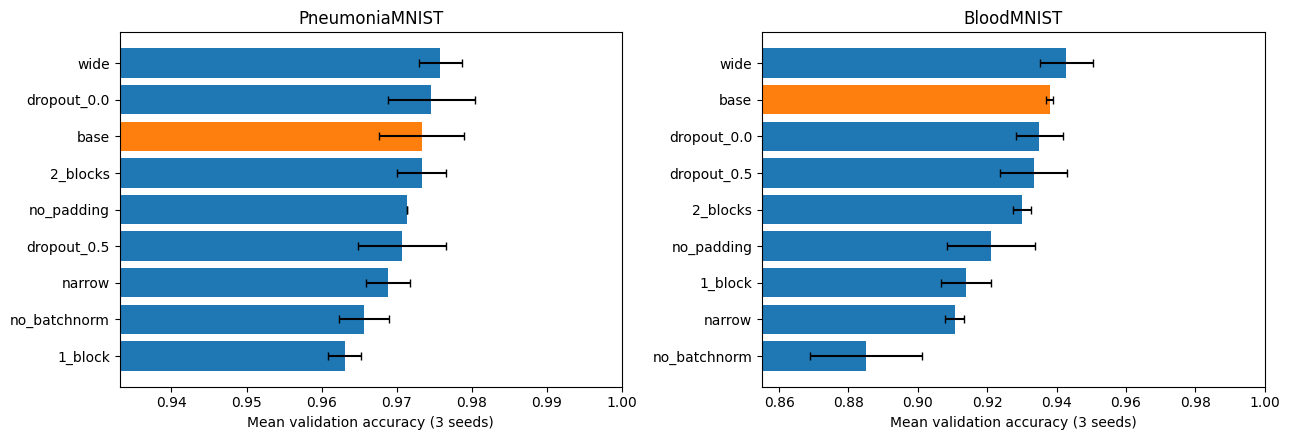

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for i, name in enumerate(["PneumoniaMNIST", "BloodMNIST"]):
    sub = summary[summary["dataset"] == name].sort_values("acc_mean")
    colors = ["tab:orange" if c == "base" else "tab:blue" for c in sub["config"]]
    ax[i].barh(sub["config"], sub["acc_mean"], xerr=sub["acc_std"], capsize=3, color=colors)
    ax[i].set_xlim(sub["acc_mean"].min() - 0.03, 1.0)
    ax[i].set_title(name)
    ax[i].set_xlabel("Mean validation accuracy (3 seeds)")

plt.tight_layout()
plt.show()

Accuracy against parameter count shows whether the larger configurations are
paying for themselves.

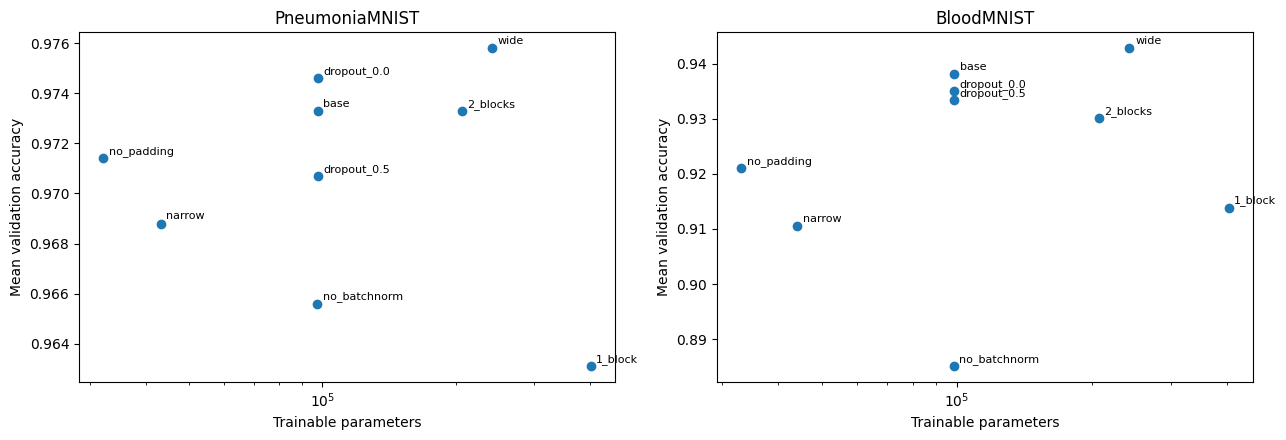

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for i, name in enumerate(["PneumoniaMNIST", "BloodMNIST"]):
    sub = summary[summary["dataset"] == name]
    ax[i].scatter(sub["params"], sub["acc_mean"])
    for _, r in sub.iterrows():
        ax[i].annotate(r["config"], (r["params"], r["acc_mean"]), fontsize=8,
                       xytext=(4, 3), textcoords="offset points")
    ax[i].set_xscale("log")
    ax[i].set_xlabel("Trainable parameters")
    ax[i].set_ylabel("Mean validation accuracy")
    ax[i].set_title(name)

plt.tight_layout()
plt.show()

## 8. Final evaluation

The configuration with the highest mean validation accuracy is retrained and
evaluated on the test set. This is the only point at which test data is used.

In [36]:
def best_config(dataset_name):
    sub = summary[summary["dataset"] == dataset_name].sort_values("acc_mean", ascending=False)
    name = sub.iloc[0]["config"]
    return next(c for c in configs if c["name"] == name)


def final_evaluation(loaders, in_channels, n_classes, class_names, dataset_name):
    cfg = best_config(dataset_name)
    print("Selected configuration:", cfg["name"])
    print(cfg["params"])

    model, history, val_acc, val_auc = run_config(loaders, in_channels, n_classes, cfg, seed=0)
    test_loss, test_acc, test_auc, y_true, y_pred = evaluate(model, loaders["test"])

    print(f"\nValidation  acc {val_acc:.4f}  auc {val_auc:.4f}")
    print(f"Test        acc {test_acc:.4f}  auc {test_auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    plot_history(history, f"{dataset_name} - {cfg['name']}")

    return {"dataset": dataset_name, "config": cfg["name"],
            "test_acc": test_acc, "test_auc": test_auc}

Selected configuration: wide
{'channels': (32, 64, 128), 'use_bn': True, 'padding': 1, 'dropout': 0.3, 'fc_dim': 128}

Validation  acc 0.9733  auc 0.9965
Test        acc 0.8830  auc 0.9655

              precision    recall  f1-score   support

      normal      0.950     0.726     0.823       234
   pneumonia      0.856     0.977     0.913       390

    accuracy                          0.883       624
   macro avg      0.903     0.852     0.868       624
weighted avg      0.891     0.883     0.879       624



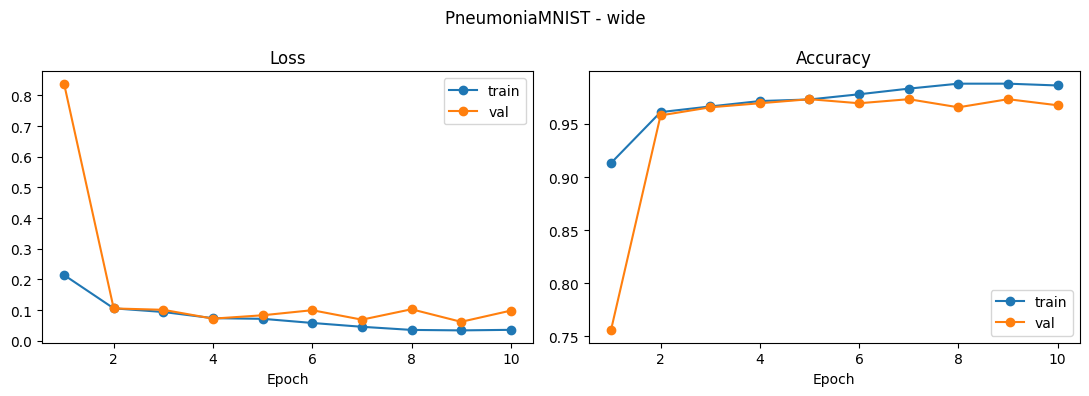

In [37]:
pneu_final = final_evaluation(pneu_loaders, pneu_ch, pneu_cls, pneu_names, "PneumoniaMNIST")

Selected configuration: wide
{'channels': (32, 64, 128), 'use_bn': True, 'padding': 1, 'dropout': 0.3, 'fc_dim': 128}

Validation  acc 0.9346  auc 0.9971
Test        acc 0.9298  auc 0.9961

                                                                     precision    recall  f1-score   support

                                                           basophil      0.897     0.889     0.893       244
                                                         eosinophil      0.992     0.971     0.981       624
                                                       erythroblast      0.973     0.916     0.944       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)      0.907     0.770     0.833       579
                                                         lymphocyte      0.836     0.988     0.906       243
                                                           monocyte      0.763     0.954     0.848       284
                                              

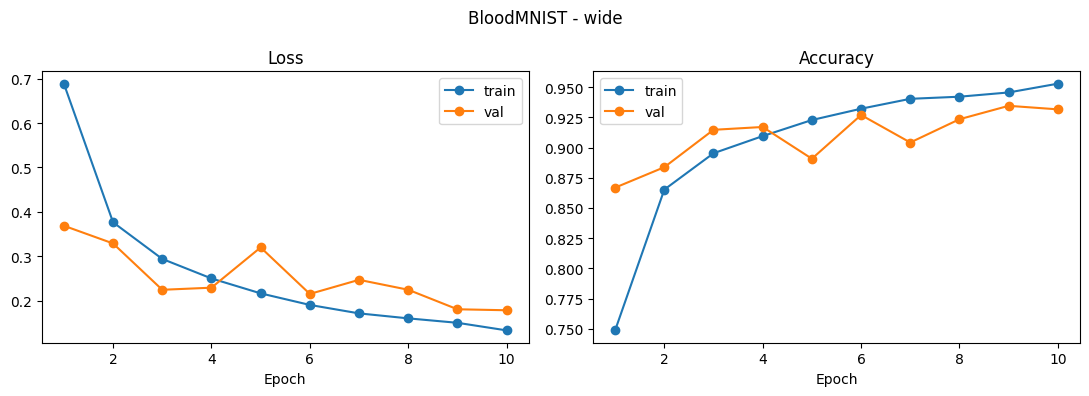

In [38]:
blood_final = final_evaluation(blood_loaders, blood_ch, blood_cls, blood_names, "BloodMNIST")

## 9. Summary

In [39]:
pd.DataFrame([pneu_final, blood_final]).round(4)

,dataset,config,test_acc,test_auc
0,PneumoniaMNIST,wide,0.8830,0.9655
1,BloodMNIST,wide,0.9298,0.9961
